/tmp/ipykernel_2425/1650342350.py:54: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_m

Dropped 0.5% entries from factor data: 0.5% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-95150.351562,28.097834,-343.381920,4693.995960,17882,20.171233
2,-141.032333,31.043335,3.383997,20.187549,17660,19.920813
3,-107.099350,37.893646,11.214676,16.058636,17647,19.906149
4,-85.643791,47.817177,16.811688,13.459231,17660,19.920813
5,-61.484577,78.311020,24.106392,11.749300,17802,20.080992


Returns Analysis


,1D,5D,10D
Ann. alpha,0.107,0.099,0.080
beta,-0.007,0.004,0.023
Mean Period Wise Return Top Quantile (bps),5.868,5.063,5.646
Mean Period Wise Return Bottom Quantile (bps),-1.370,-3.133,-3.563
Mean Period Wise Spread (bps),7.238,8.306,9.365


<Figure size 640x480 with 0 Axes>

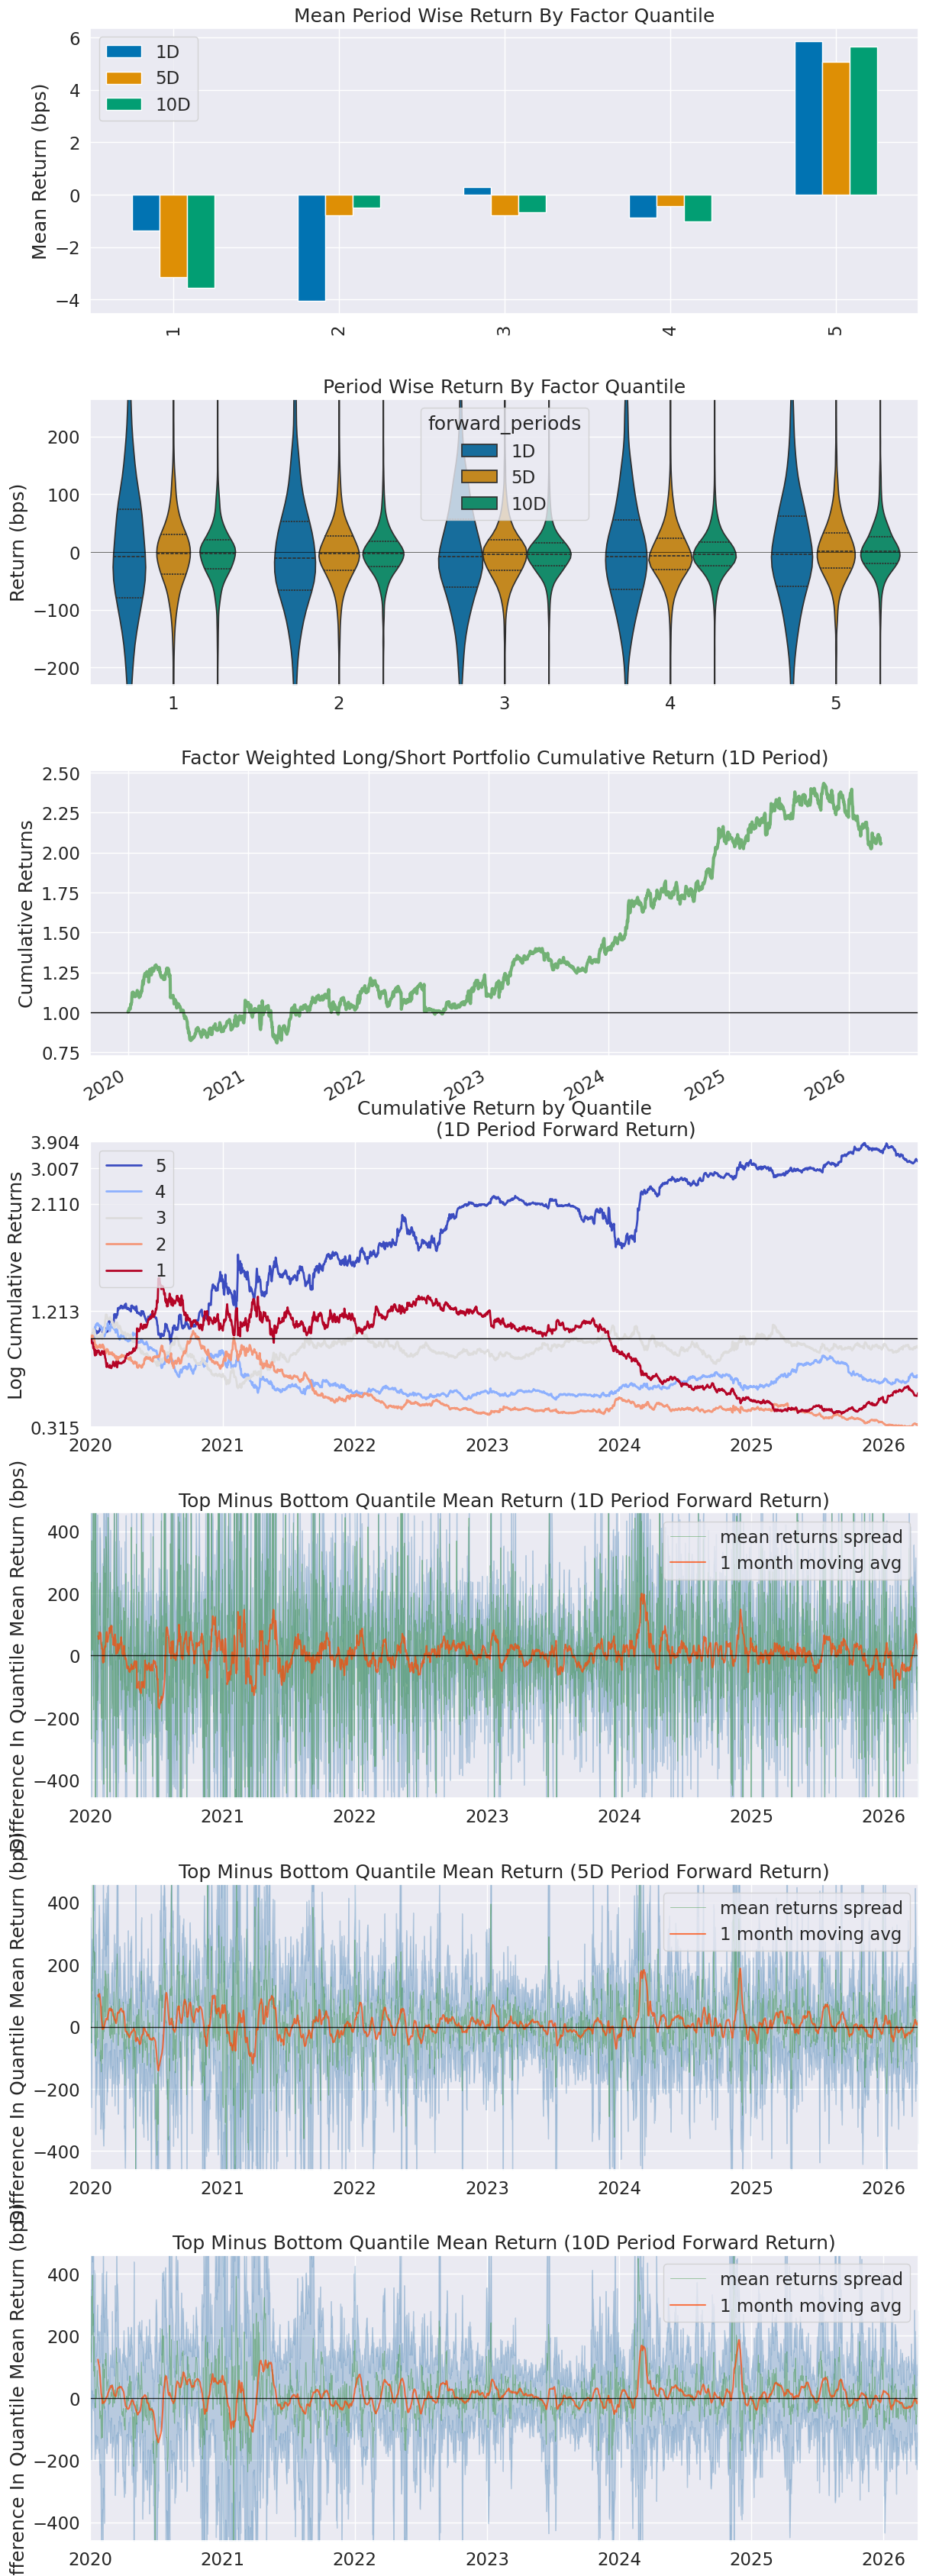

Information Analysis


,1D,5D,10D
IC Mean,0.020,0.019,0.027
IC Std.,0.207,0.210,0.208
Risk-Adjusted IC,0.099,0.091,0.131
t-stat(IC),4.729,4.365,6.277
p-value(IC),0.000,0.000,0.000
IC Skew,0.003,0.038,0.076
IC Kurtosis,-0.296,-0.145,-0.254


/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


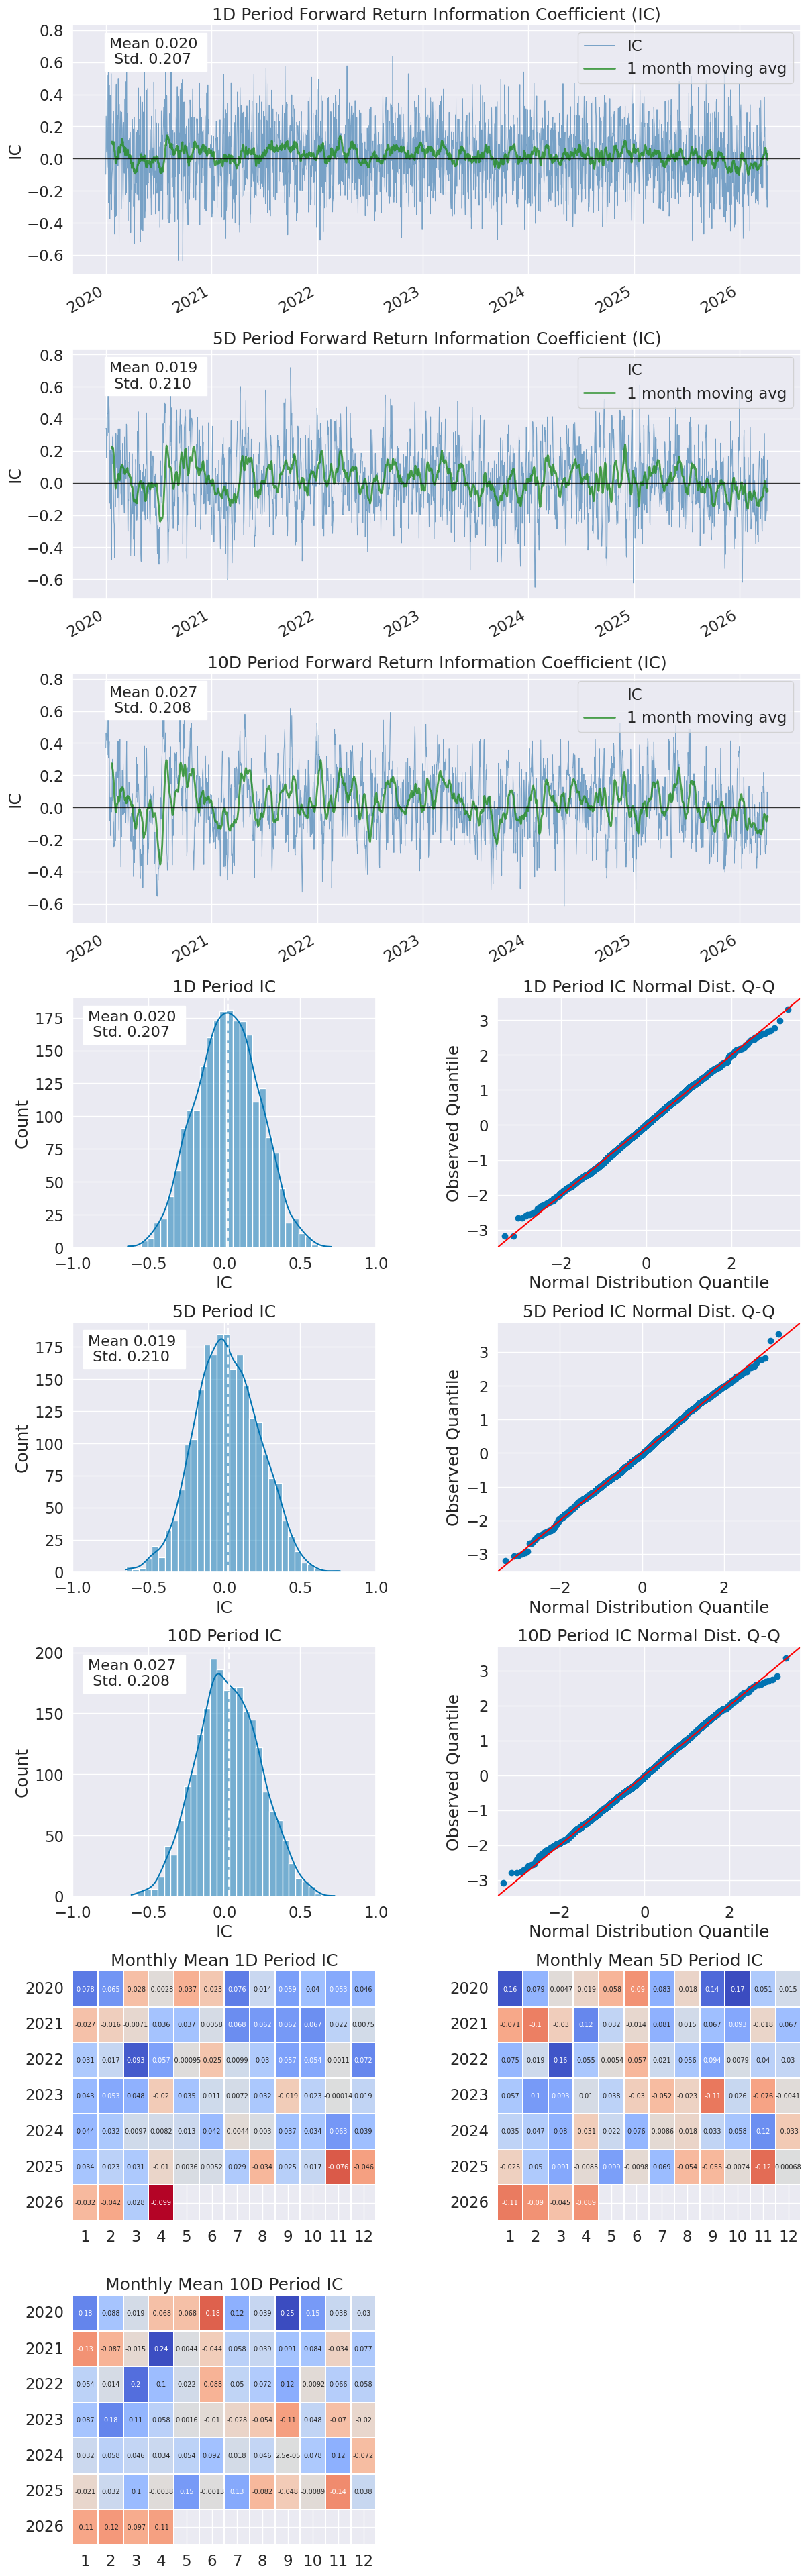

/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.310,0.497,0.584
Quantile 2 Mean Turnover,0.538,0.669,0.711
Quantile 3 Mean Turnover,0.574,0.700,0.729
Quantile 4 Mean Turnover,0.541,0.666,0.705
Quantile 5 Mean Turnover,0.311,0.460,0.527


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.81,0.622,0.533


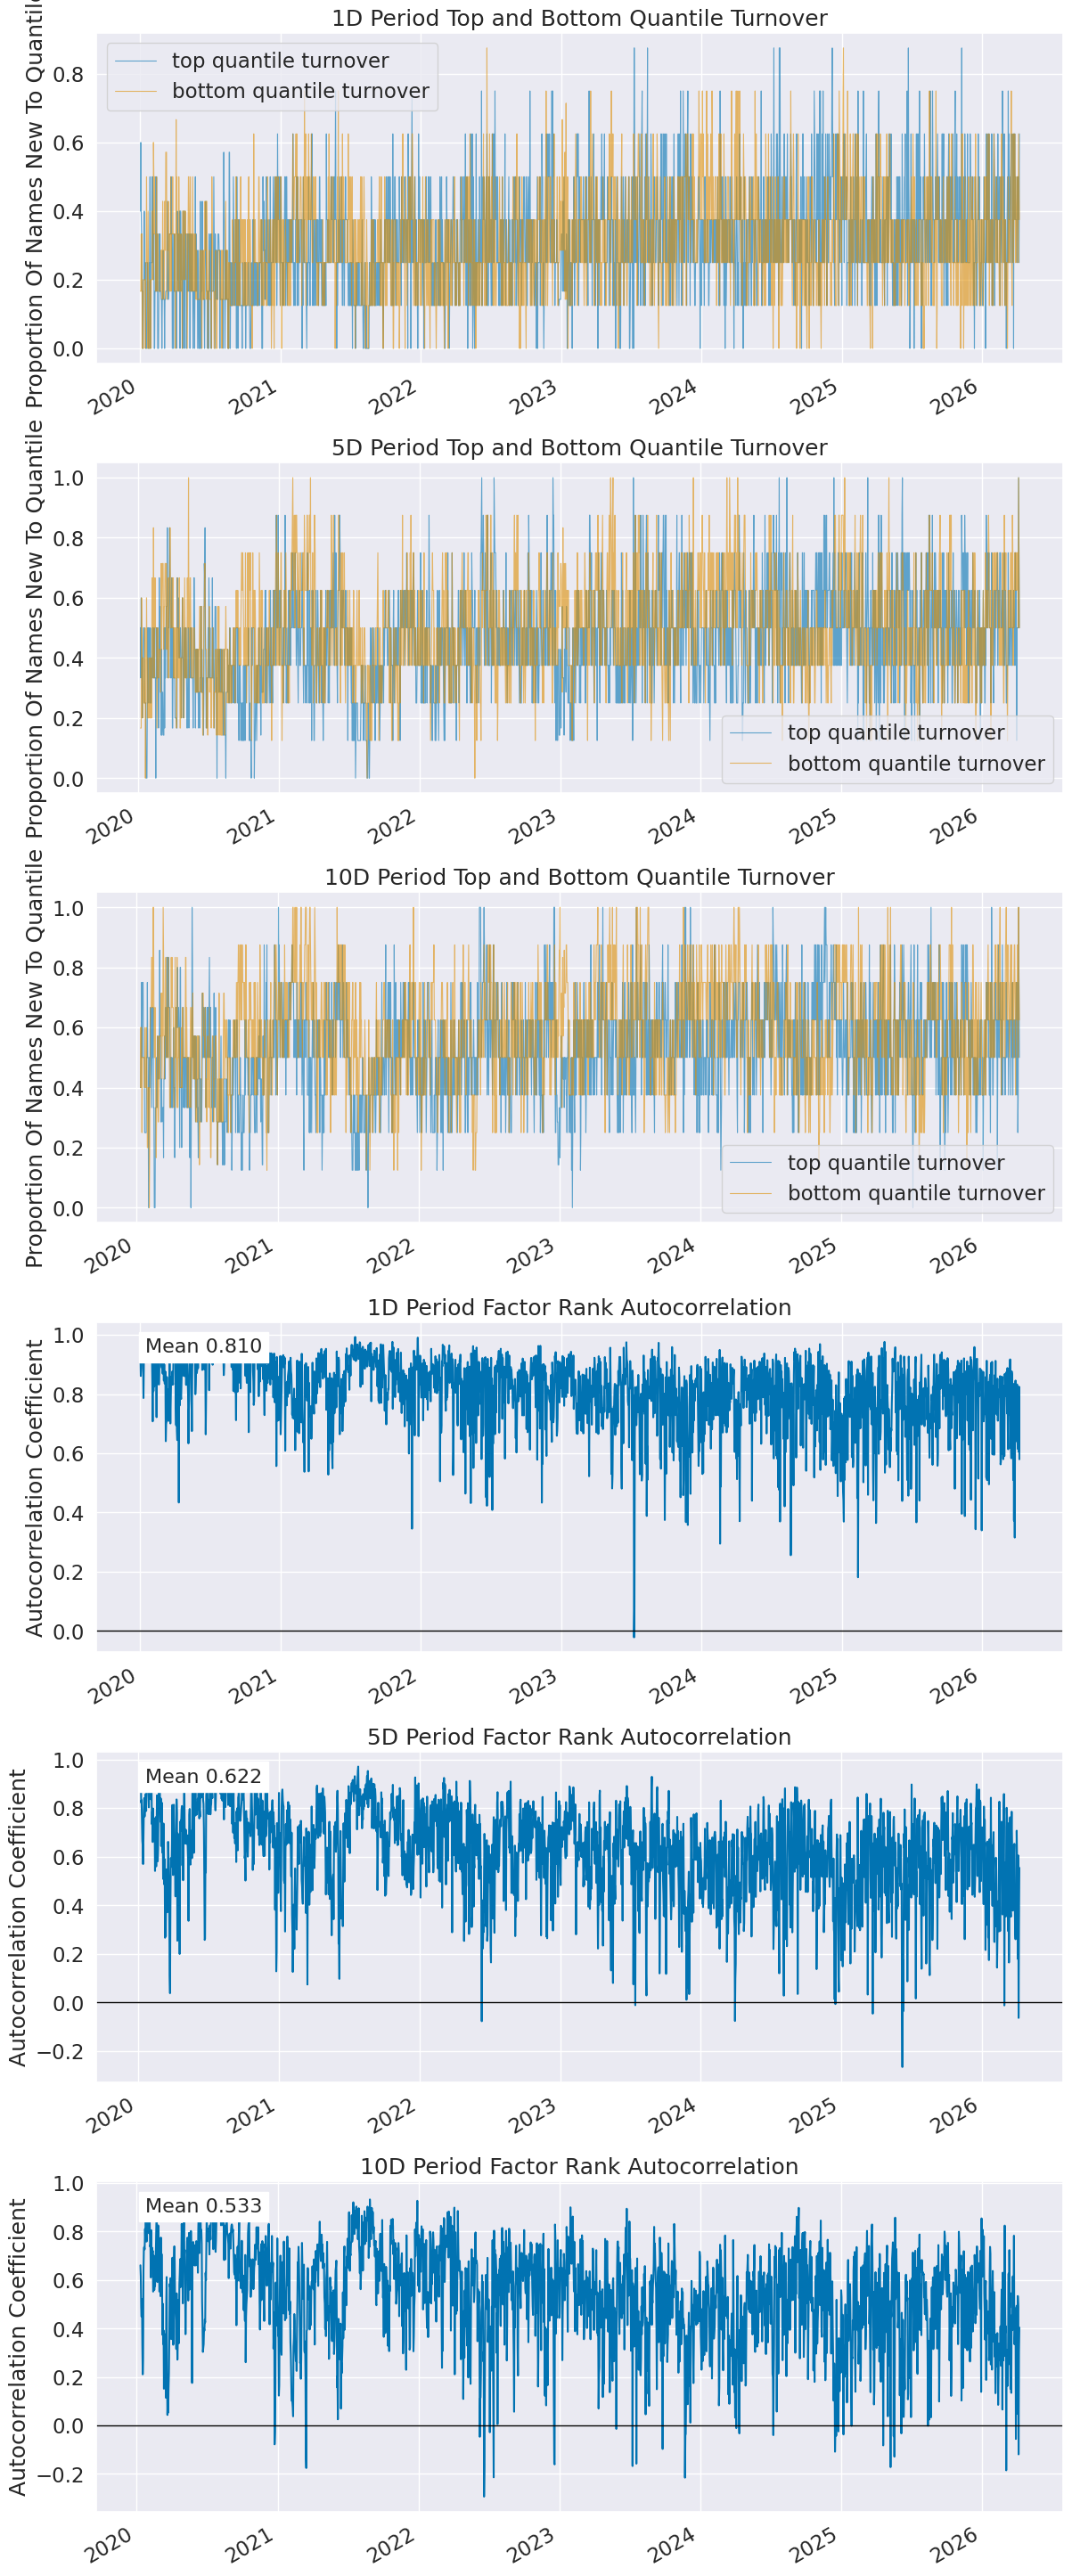

In [1]:
# AUTO-GENERATED by scripts/generate_factor_notebooks.py from
# scripts/factors_catalog.py -- do not edit by hand. Re-run the
# generator (or the "Generate Notebooks" workflow) to refresh.
import sys
from pathlib import Path

_repo_root = Path.cwd()
while not (_repo_root / "analysis").is_dir() and _repo_root != _repo_root.parent:
    _repo_root = _repo_root.parent
sys.path.insert(0, str(_repo_root))

from unravel_client import (
    get_historical_universe,
    get_portfolio_factors_historical,
    get_prices,
    get_tickers,
)

from analysis.alphalens import factor_analysis
from analysis.utils import get_env

UNRAVEL_API_KEY = get_env("UNRAVEL_API_KEY")

# Enhanced Mean Reversion -- portfolio mean_reversion_enhanced.40
portfolio = "mean_reversion_enhanced"
universe_size = "40"

available_tickers = get_tickers(
    id=portfolio,
    api_key=UNRAVEL_API_KEY,
    universe_size=universe_size,
    exchange=None,
)
historical_factors = get_portfolio_factors_historical(
    id=portfolio, tickers=available_tickers, api_key=UNRAVEL_API_KEY
)
underlying = get_prices(tickers=available_tickers, api_key=UNRAVEL_API_KEY)

# Restrict the analysis to the *dynamic* point-in-time universe rather than
# every ticker that was ever tradeable. get_historical_universe returns a
# boolean membership matrix (dates x tickers); masking the raw factor with it
# drops each asset on the days it was out of universe, so AlphaLens scores
# the factor on the universe we actually trade.
universe = get_historical_universe(
    size=universe_size,
    api_key=UNRAVEL_API_KEY,
    start_date=str(historical_factors.index.min().date()),
    end_date=str(historical_factors.index.max().date()),
)
membership = (
    universe.reindex(index=historical_factors.index)
    .ffill()
    .reindex(columns=historical_factors.columns)
    .fillna(False)
    .astype(bool)
)
restricted_factors = historical_factors.where(membership)

columns_intersection = restricted_factors.columns.intersection(underlying.columns)
factor_analysis(restricted_factors[columns_intersection], underlying)